In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("student_performance.csv")

In [6]:
df.head()

,Hours_Studied,Attendance,Assignments,Sleep_Hours,Previous_Score,Final_Score
0,2,65,55,6,50,54
1,3,70,60,7,55,59
2,4,75,65,6,60,64
3,5,80,70,7,65,70
4,6,85,75,8,70,76


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43 entries, 0 to 42
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Hours_Studied   43 non-null     int64
 1   Attendance      43 non-null     int64
 2   Assignments     43 non-null     int64
 3   Sleep_Hours     43 non-null     int64
 4   Previous_Score  43 non-null     int64
 5   Final_Score     43 non-null     int64
dtypes: int64(6)
memory usage: 2.1 KB


In [8]:
df. shape

(43, 6)

In [9]:
df.describe()

,Hours_Studied,Attendance,Assignments,Sleep_Hours,Previous_Score,Final_Score
count,43.000000,43.000000,43.000000,43.000000,43.000000,43.000000
mean,5.186047,80.627907,72.674419,6.860465,66.906977,72.255814
std,2.519031,11.385085,13.070725,0.914991,12.718217,14.354513
min,1.000000,58.000000,48.000000,5.000000,44.000000,48.000000
25%,3.000000,71.500000,62.500000,6.000000,56.500000,60.500000
50%,5.000000,82.000000,73.000000,7.000000,67.000000,72.000000
75%,7.000000,90.500000,83.500000,8.000000,77.500000,83.500000
max,9.000000,98.000000,94.000000,8.000000,88.000000,97.000000


In [10]:
df.isnull().sum()

Hours_Studied     0
Attendance        0
Assignments       0
Sleep_Hours       0
Previous_Score    0
Final_Score       0
dtype: int64

In [11]:
X = df[['Hours_Studied',
        'Attendance',
        'Assignments',
        'Sleep_Hours',
        'Previous_Score']]

y = df['Final_Score']

In [ ]:
print(X.head())
print(y.head())

   Hours_Studied  Attendance  Assignments  Sleep_Hours  Previous_Score
0              2          65           55            6              50
1              3          70           60            7              55
2              4          75           65            6              60
3              5          80           70            7              65
4              6          85           75            8              70
0    54
1    59
2    64
3    70
4    76
Name: Final_Score, dtype: int64


In [13]:
#train-test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [14]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(34, 5)
(9, 5)
(34,)
(9,)


## Model Training:-

In [15]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](5,)","[ 1.23,-0.19, 0.26, 0.46, 0.78]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](5,)","['Hours_Studied','Attendance','Assignments','Sleep_Hours','Previous_Score']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,6.806
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(5)


In [20]:
## making predicctions:
y_pred = model.predict(X_test)
y_pred_rounded = y_pred.round().astype(int)
#making decimals disappear and converting to int.
print(y_pred_rounded)

[65 89 95 60 46 77 76 73 47]


In [22]:
y_pred_rounded = y_pred.round().astype(int)

print("Actual:", y_test.values)
print("Predicted:", y_pred_rounded)

Actual: [65 87 95 60 48 76 76 72 49]
Predicted: [65 89 95 60 46 77 76 73 47]


In [23]:
# evaluating the model:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)

print("MAE:", mae)

MAE: 1.0553108571606715


means that the model's prediaction is off by 1.055 mark to be precise

In [25]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred)

print("MSE:", mse)

MSE: 1.7893977136367414


What does MSE mean?

MSE = Mean Squared Error

It takes each prediction error, squares it, and then averages those squared errors.

In [26]:
from sklearn.metrics import root_mean_squared_error

rmse = root_mean_squared_error(y_test, y_pred)

print("RMSE:", rmse)

RMSE: 1.3376837121071414


What does RMSE mean?

RMSE = Root Mean Squared Error

It is basically the square root of MSE

In [27]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

R² Score: 0.9921038780341809


#### R² (R-squared) tells us how well our input variables explain the variation in Final_Score.

In [28]:
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

Intercept: 6.805926518575191
Coefficients: [ 1.22677943 -0.18828944  0.2641594   0.4602119   0.77648593]


#### Coefficient:
Each coefficient tells us how the predicted Final Score changes when that particular feature increases by 1 unit, while the other features stay the same.

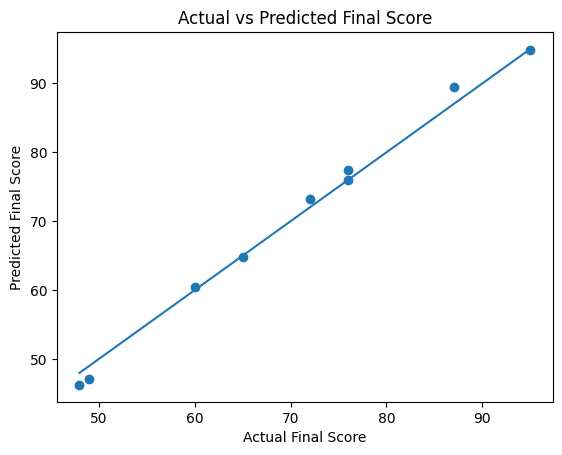

In [29]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()])

plt.xlabel("Actual Final Score")
plt.ylabel("Predicted Final Score")
plt.title("Actual vs Predicted Final Score")

plt.show()

## Conclusion:-

We are making a graph to compare what the students actually scored with what our Linear Regression model predicted.

And because your model has R² = 0.9921, your points should be very close to the diagonal line, which indicates very good predictions.